# CNN and VGG16 Comparison

This notebook compares two custom CNN architectures with a VGG16 model.

It includes:
- Sample images
- Model architectures
- Model summaries
- Confusion matrices

## Imports and Dataset Loading

In [71]:

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input
import cv2
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [13]:
import tensorflow as tf
import matplotlib.pyplot as plt

## Load Dataset

In [140]:
import os
import kagglehub
from tensorflow.keras.preprocessing.image import ImageDataGenerator

base = kagglehub.dataset_download('rashikrahmanpritom/plant-disease-recognition-dataset')

trainpth, valpth, testpth = [
    os.path.join(base, x)
    for x in ['Train/Train', 'Validation/Validation', 'Test/Test']
]

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# ---------- For VGG16 (ImageNet preprocessing) ----------
train_datagen_vgg = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen_vgg = ImageDataGenerator(
    preprocessing_function=preprocess_input
)


train_gen_vgg = train_datagen_vgg.flow_from_directory(
    trainpth,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_gen_vgg = val_datagen_vgg.flow_from_directory(
    valpth,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# ---------- For small CNN from scratch (simple rescale) ----------
train_datagen_scratch = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen_scratch = ImageDataGenerator(rescale=1./255)

train_gen_scratch = train_datagen_scratch.flow_from_directory(
    trainpth,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_gen_scratch = val_datagen_scratch.flow_from_directory(
    valpth,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

#--------- Test -------------------

test_datagen_scratch = ImageDataGenerator(rescale=1./255)

test_gen_scratch = test_datagen_scratch.flow_from_directory(
    testpth,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_datagen_vgg = ImageDataGenerator(preprocessing_function=preprocess_input)

test_gen_vgg = test_datagen_vgg.flow_from_directory(
    testpth,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)



Found 1322 images belonging to 3 classes.
Found 60 images belonging to 3 classes.
Found 1322 images belonging to 3 classes.
Found 60 images belonging to 3 classes.
Found 150 images belonging to 3 classes.
Found 150 images belonging to 3 classes.


In [90]:
def show_sample_images(data_path, classes):
    # Create 1 row and N columns (where N is the number of classes)
    # figsize width is increased to 15 to fit images side-by-side
    fig, axs = plt.subplots(1, len(classes), figsize=(15, 5))

    # Handle the case where there's only 1 class to keep axs indexable
    if len(classes) == 1:
        axs = [axs]

    for i, class_name in enumerate(classes):
        class_folder = os.path.join(data_path, class_name)
        
        # Filter to make sure we only grab image files (ignores .DS_Store etc.)
        images = [f for f in os.listdir(class_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        if images:
            img_path = os.path.join(class_folder, images[0]) # Get the first image
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            ax = axs[i]
            ax.imshow(img)
            ax.set_title(f"{class_name}", fontsize=12, fontweight='bold')
            
            # Keep the axes and grid as per your requirements
            ax.set_xticks([0, img.shape[1]//2, img.shape[1]-1])
            ax.set_yticks([0, img.shape[0]//2, img.shape[0]-1])
            ax.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.3)
            ax.tick_params(axis='both', which='major', labelsize=8)
        else:
            axs[i].set_title(f"{class_name} (No Image Found)")
            axs[i].axis('off')

    plt.suptitle("Horizontal Sample Images from Each Class", fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()

In [92]:
show_sample_images(trainpth, ['Healthy', 'Powdery', 'Rust'])

NameError: name 'show_sample_images' is not defined

## Training Sample Images

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-106.68..151.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-98.68..151.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-102.68..134.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-99.68..149.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-102.68..151.061].


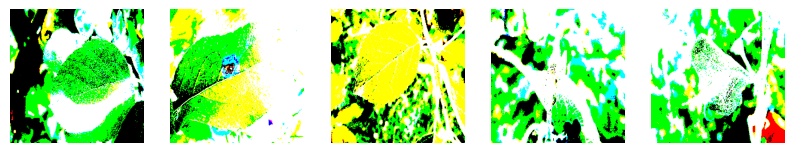

In [28]:

images, labels = next(vgg_train_gen)
plt.figure(figsize=(10,5))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i])
    plt.axis('off')
plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-103.939..151.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-116.68..151.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-118.68..149.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-103.939..151.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-98.939..151.061].


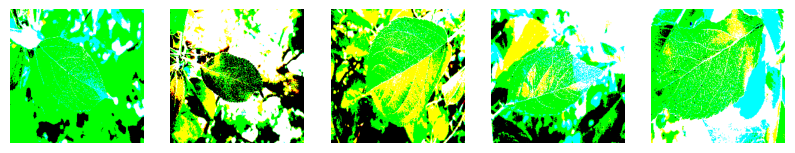

In [29]:
images, labels = next(cnn_train_gen)
plt.figure(figsize=(10,5))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i])
    plt.axis('off')
plt.show()

## CNN Model

In [ ]:
EPOCHS = 26

# ----- Small custom CNN from scratch -----
model_scratch = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    
    # Conv block 1
    layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    # Conv block 2
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    # Classifier
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax')
])

model_scratch.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_scratch.summary()

# ----- Train -----
history_scratch = model_scratch.fit(
    train_gen_scratch,
    epochs=EPOCHS,
    validation_data=val_gen_scratch
)

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │     6,422,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,427,875 (24.52 MB)

 Trainable params: 6,427,875 (24.52 MB)

 Non-trainable params: 0 (0.00 B)

/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/26
42/42 ━━━━━━━━━━━━━━━━━━━━ 134s 3s/step - accuracy: 0.4357 - loss: 1.2739 - val_accuracy: 0.5500 - val_loss: 1.0105
Epoch 2/26
42/42 ━━━━━━━━━━━━━━━━━━━━ 129s 3s/step - accuracy: 0.5643 - loss: 0.9007 - val_accuracy: 0.5833 - val_loss: 0.8443
Epoch 3/26
42/42 ━━━━━━━━━━━━━━━━━━━━ 1686s 41s/step - accuracy: 0.6581 - loss: 0.7681 - val_accuracy: 0.8167 - val_loss: 0.6056
Epoch 4/26
42/42 ━━━━━━━━━━━━━━━━━━━━ 237s 6s/step - accuracy: 0.7118 - loss: 0.6906 - val_accuracy: 0.8000 - val_loss: 0.6040
Epoch 5/26
42/42 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.7965 - loss: 0.5360 - val_accuracy: 0.8500 - val_loss: 0.4799
Epoch 6/26
42/42 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.7829 - loss: 0.4973 - val_accuracy: 0.8333 - val_loss: 0.4065
Epoch 7/26
42/42 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.8124 - loss: 0.4683 - val_accuracy: 0.9000 - val_loss: 0.3720
Epoch 8/26
42/42 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.7950 - loss: 0.5004 - val_accuracy: 0.8667 - val

## VGG16 Model

In [36]:
# Transfer Learning Model

# ----- VGG16 base model -----
base_model = VGG16(
    weights='imagenet',
    include_top=False,         
    input_shape=(224, 224, 3)
)

# Freeze convolutional base
base_model.trainable = False

# ----- Add custom classifier head -----
inputs = layers.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(3, activation='softmax')(x)

model_vgg = models.Model(inputs, outputs)

model_vgg.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_vgg.summary()


Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_18 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,787 (56.64 MB)

 Trainable params: 132,099 (516.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [94]:
EPOCHS = 30
# ----- Train -----
history_vgg = model_vgg.fit(
    train_gen_vgg,
    epochs=EPOCHS,
    validation_data=val_gen_vgg
)



Epoch 1/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 142s 3s/step - accuracy: 0.9486 - loss: 0.1578 - val_accuracy: 0.9500 - val_loss: 0.1211
Epoch 2/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 140s 3s/step - accuracy: 0.9327 - loss: 0.1641 - val_accuracy: 0.9500 - val_loss: 0.1495
Epoch 3/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 135s 3s/step - accuracy: 0.9531 - loss: 0.1219 - val_accuracy: 0.9500 - val_loss: 0.1365
Epoch 4/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 134s 3s/step - accuracy: 0.9561 - loss: 0.1165 - val_accuracy: 0.9500 - val_loss: 0.1444
Epoch 5/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 135s 3s/step - accuracy: 0.9531 - loss: 0.1262 - val_accuracy: 0.9500 - val_loss: 0.1286
Epoch 6/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 134s 3s/step - accuracy: 0.9523 - loss: 0.1354 - val_accuracy: 0.9500 - val_loss: 0.1328
Epoch 7/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 1174s 29s/step - accuracy: 0.9576 - loss: 0.1389 - val_accuracy: 0.9500 - val_loss: 0.1156
Epoch 8/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 2119s 52s/step - accuracy: 0.9523 - loss: 0.1315 - val_accuracy: 0.9500

In [ ]:

# ----- Optional: fine-tune last few layers -----
base_model.trainable = True
for layer in base_model.layers[:-4]:   # keep all but last 4 layers frozen
    layer.trainable = False

model_vgg.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_vgg_fine = model_vgg.fit(
    train_gen_vgg,
    epochs=5,
    validation_data=val_gen_vgg
)

In [96]:
# Save the trained model
model_vgg.save("vgg16_transfer_learning.keras")

# Save the scratch model
model_scratch.save("scratch_cnn.keras")

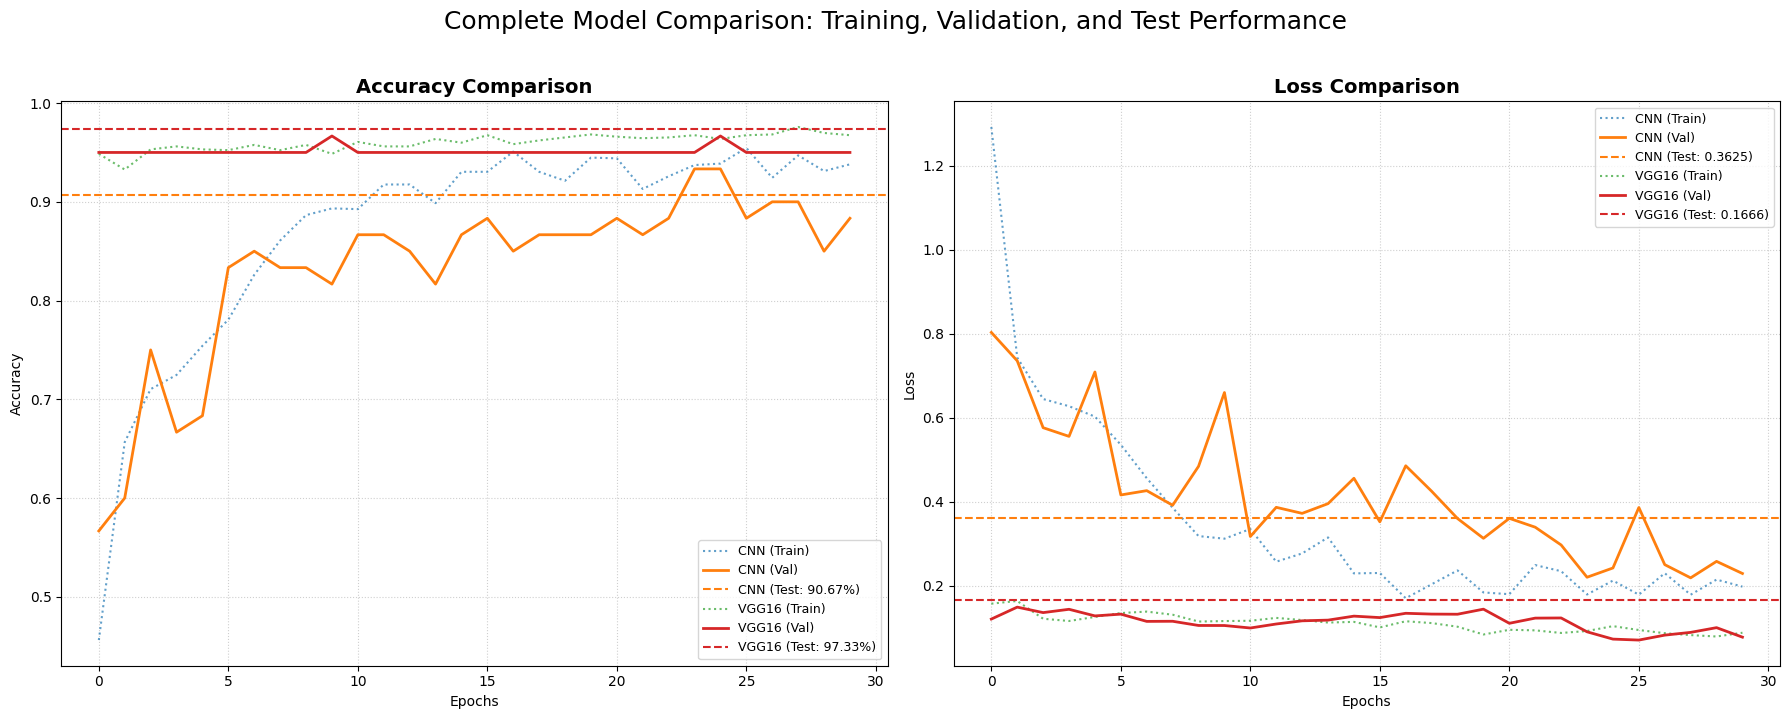

In [143]:
def plot_comparison_with_test(histories, titles, test_metrics):
    """
    histories: list of history objects [history_cnn, history_vgg]
    titles: list of labels ['CNN Scratch', 'VGG16']
    test_metrics: list of tuples [(test_loss_cnn, test_acc_cnn), (test_loss_vgg, test_acc_vgg)]
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] 

    for i, (history, name, metrics) in enumerate(zip(histories, titles, test_metrics)):
        test_loss, test_acc = metrics
        epochs = range(len(history.history['accuracy']))
        
        # --- Plot Accuracy ---
        ax1.plot(history.history['accuracy'], label=f'{name} (Train)', 
                 linestyle=':', color=colors[i*2], alpha=0.7)
        ax1.plot(history.history['val_accuracy'], label=f'{name} (Val)', 
                 linewidth=2, color=colors[i*2+1])
        # Add Test Accuracy as a solid horizontal line
        ax1.axhline(y=test_acc, color=colors[i*2+1], linestyle='--', 
                    label=f'{name} (Test: {test_acc:.2%})')
        
        # --- Plot Loss ---
        ax2.plot(history.history['loss'], label=f'{name} (Train)', 
                 linestyle=':', color=colors[i*2], alpha=0.7)
        ax2.plot(history.history['val_loss'], label=f'{name} (Val)', 
                 linewidth=2, color=colors[i*2+1])
        # Add Test Loss as a solid horizontal line
        ax2.axhline(y=test_loss, color=colors[i*2+1], linestyle='--', 
                    label=f'{name} (Test: {test_loss:.4f})')

    # Styling
    ax1.set_title('Accuracy Comparison', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Accuracy')
    ax2.set_title('Loss Comparison', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Loss')

    for ax in [ax1, ax2]:
        ax.set_xlabel('Epochs')
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(loc='best', frameon=True, fontsize=9)

    plt.suptitle("Complete Model Comparison: Training, Validation, and Test Performance", fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()

# --- HOW TO RUN ---

# 1. First, get the test metrics for both models
test_metrics_scratch = model_scratch.evaluate(test_gen_scratch, verbose=0)
test_metrics_vgg = model_vgg.evaluate(test_gen_vgg, verbose=0)

# 2. Run the plotter
plot_comparison_with_test(
    [history_scratch, history_vgg], 
    ['CNN', 'VGG16'], 
    [test_metrics_scratch, test_metrics_vgg]
)

## Confusion Matrix

5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step


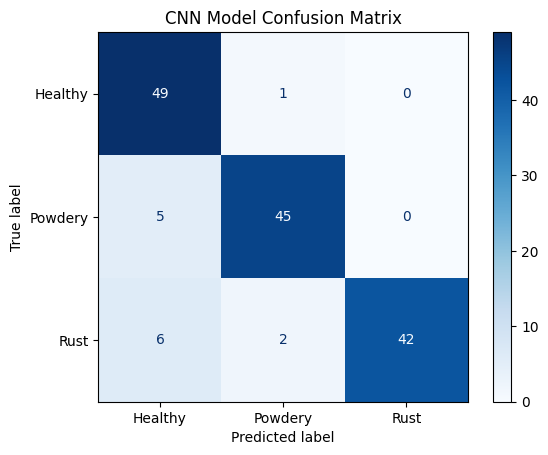

5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step


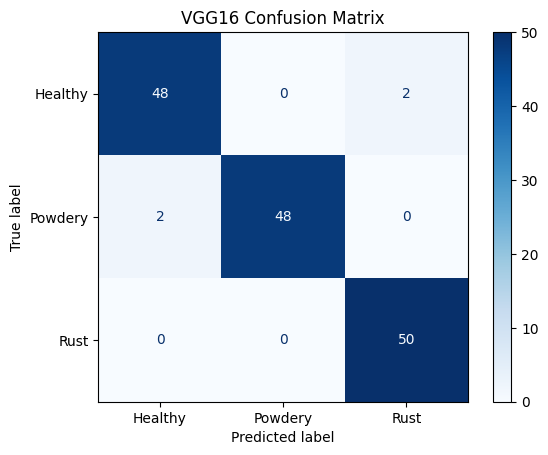

In [142]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

def plot_confusion_matrix(model, generator, title):
    predictions = model.predict(generator)
    y_pred = np.argmax(predictions, axis=1)
    y_true = generator.classes

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=generator.class_indices.keys()
    )
    disp.plot(cmap='Blues')
    plt.title(title)
    plt.show()

plot_confusion_matrix(model_scratch, test_gen_scratch, "CNN Model Confusion Matrix")
plot_confusion_matrix(model_vgg, test_gen_vgg, "VGG16 Confusion Matrix")

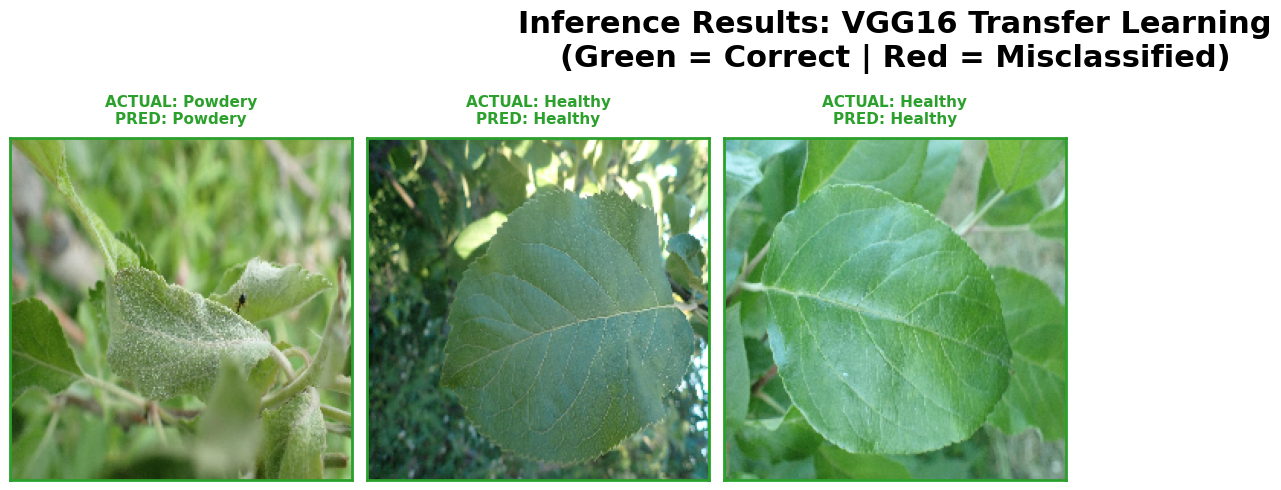

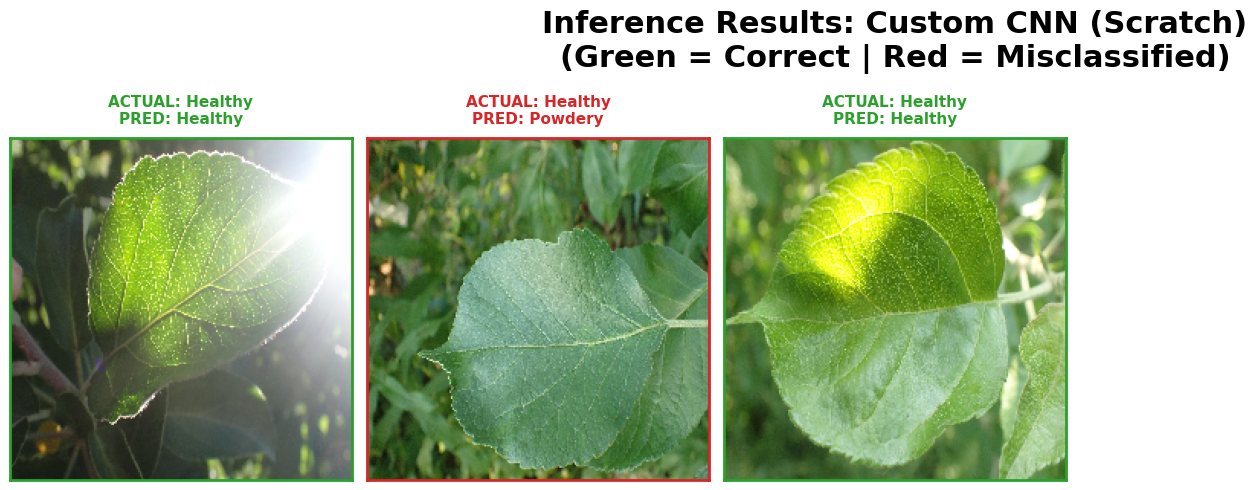

In [144]:
def plot_random_predictions(model, generator, model_name="Model", num_samples=3):
    """
    Selects random samples from an ImageDataGenerator and displays them 
    in a clean grid with color-coded Actual vs Predicted labels.
    """
    # 1. Pick a random batch index
    num_batches = len(generator)
    random_batch_idx = np.random.randint(0, num_batches)
    
    # 2. Get that specific batch
    images, labels = generator[random_batch_idx]
    
    # 3. Get predictions for this batch
    predictions = model.predict(images, verbose=0)
    
    # 4. Convert to class names
    pred_indices = np.argmax(predictions, axis=1)
    true_indices = np.argmax(labels, axis=1)
    idx_to_class = {v: k for k, v in generator.class_indices.items()}
    
    # 5. Determine grid size (max 5 columns)
    num_to_show = min(num_samples, len(images))
    cols = 5
    rows = (num_to_show + cols - 1) // cols
    
    # 6. Pick random indices from within this batch
    sample_indices = np.random.choice(range(len(images)), num_to_show, replace=False)
    
    plt.figure(figsize=(18, 5 * rows))
    
    for i, idx in enumerate(sample_indices):
        plt.subplot(rows, cols, i + 1)
        
        img = images[idx]
        
        # --- DEPROCESSING FOR VISUALIZATION ---
        if img.min() < 0: # Check if VGG-style preprocessing was applied
            img = img.copy()
            img[:, :, 0] += 103.939
            img[:, :, 1] += 116.779
            img[:, :, 2] += 123.68
            img = img[:, :, ::-1] # BGR to RGB
            
        img = np.clip(img, 0, 255).astype('uint8')
        
        plt.imshow(img)
        
        actual_name = idx_to_class[true_indices[idx]]
        pred_name = idx_to_class[pred_indices[idx]]
        
        # Set color: Green if correct, Red if incorrect
        is_correct = actual_name == pred_name
        title_color = '#2ca02c' if is_correct else '#d62728' # Professional Green/Red
        
        plt.title(f"ACTUAL: {actual_name}\nPRED: {pred_name}", 
                  color=title_color, 
                  fontsize=11, 
                  fontweight='bold',
                  pad=10)
        
        # Optional: add a border color based on result
        plt.gca().spines['top'].set_visible(True)
        plt.gca().spines['bottom'].set_visible(True)
        plt.gca().spines['left'].set_visible(True)
        plt.gca().spines['right'].set_visible(True)
        for spine in plt.gca().spines.values():
            spine.set_edgecolor(title_color)
            spine.set_linewidth(2)
            
        plt.xticks([])
        plt.yticks([])

    # Better title including the specific model name
    plt.suptitle(f"Inference Results: {model_name}\n(Green = Correct | Red = Misclassified)", 
                 fontsize=22, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.show()

# --- HOW TO RUN ---
# Pass the model name as a string to make the title dynamic
plot_random_predictions(model_vgg, test_gen, model_name="VGG16 Transfer Learning", num_samples=3)
plot_random_predictions(model_scratch, test_gen, model_name="Custom CNN (Scratch)", num_samples=3)